# DIGITAL MODULATIONS CLASSIFIER


## INTRODUCCIÓN


#### En los sistemas de comunicación digital, las señales transmitidas utilizan diferentes tipos de modulación, como BPSK, QPSK, 8PSK, 16-QAM y 64-QAM, para representar información en forma de bits. El problema surge cuando una señal es recibida y no se conoce previamente qué tipo de modulación fue utilizada. Esta situación es común en escenarios de monitoreo del espectro radioeléctrico, análisis de señales inalámbricas, radio definida por software, comunicaciones cognitivas e identificación de interferencias. Por ello, clasificar automáticamente el tipo de modulación se convierte en una tarea importante para interpretar correctamente una señal y facilitar procesos posteriores como su análisis, demodulación o gestión.

#### El problema a resolver en este proyecto consiste en desarrollar un modelo de machine learning capaz de identificar automáticamente la modulación digital de una señal a partir de sus componentes IQ, es decir, la información en fase y cuadratura que describe el comportamiento de la señal. Esta tarea no es sencilla, porque las modulaciones pueden presentar patrones similares entre sí, especialmente cuando existe ruido en el canal o cuando se trabaja con modulaciones más complejas como 16-QAM y 64-QAM. Además, el desempeño del clasificador puede variar según el nivel de SNR, lo que hace necesario evaluar si el modelo logra aprender diferencias reales entre las clases.

#### La importancia de este problema radica en que la clasificación automática de modulaciones permite reducir la dependencia de métodos manuales o basados exclusivamente en reglas diseñadas por expertos. En este proyecto se utiliza el dataset RML2016.10A y se seleccionan cinco modulaciones digitales: BPSK, QPSK, 8PSK, QAM16 y QAM64. A partir de las señales IQ crudas se generan características derivadas como amplitud, potencia y fase circular, con el fin de enriquecer la representación de entrada. Posteriormente, se comparan dos técnicas de aprendizaje automático: una red neuronal MLP y una Regresión Logística L2. Además, se analiza el efecto del ruido mediante el SNR, se optimizan hiperparámetros con validación cruzada repetida y se realiza una comparación estadística entre modelos.

## EDA

### Cargar el archivo

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "../../data/RML2016.10a_dict.pkl"

with open(path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

### Claves del diccionario

In [3]:
keys = list(data.keys())

print("Número de combinaciones modulación-SNR:", len(keys))
print("Primeras claves:")
print(keys[:20])

Número de combinaciones modulación-SNR: 220
Primeras claves:
[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8), ('AM-SSB', 12), ('8PSK', 8), ('8PSK', 12), ('QAM64', -6), ('QAM16', 2), ('QAM16', -20), ('PAM4', -6), ('WBFM', -18), ('AM-DSB', 16), ('CPFSK', 10), ('WBFM', 6), ('BPSK', 4), ('BPSK', -2), ('QPSK', -20), ('CPFSK', -8)]


In [4]:
# Se separa modulaciones y SNR disponibles
mods = sorted(list(set([k[0] for k in keys])))
snrs = sorted(list(set([k[1] for k in keys])))

print("Modulaciones disponibles:", mods)
print("SNR disponibles:", snrs)

Modulaciones disponibles: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR disponibles: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [5]:
selected_mods = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

### Forma de los datos IQ

In [6]:
example_key = keys[0]
example_data = data[example_key]

print("Clave ejemplo:", example_key)
print("Forma del arreglo:", example_data.shape)

Clave ejemplo: ('QPSK', 2)
Forma del arreglo: (1000, 2, 128)


##### El dataset está organizado como un diccionario donde cada clave corresponde a una combinación entre modulación y SNR. Cada clave tiene la forma (modulación, SNR), por ejemplo ('QPSK', 18). El valor asociado a cada clave es un arreglo con forma (1000, 2, 128), donde 1000 representa el número de señales, 2 corresponde a los canales I y Q, y 128 representa las muestras temporales de cada señal.

### DataFrame resumen del dataset

In [7]:
summary = []

for (mod, snr), samples in data.items():
    summary.append({
        "modulation": mod,
        "snr": snr,
        "num_samples": samples.shape[0],
        "channels": samples.shape[1],
        "signal_length": samples.shape[2]
    })

df_summary = pd.DataFrame(summary)
df_summary.head()

,modulation,snr,num_samples,channels,signal_length
0,QPSK,2,1000,2,128
1,PAM4,8,1000,2,128
2,AM-DSB,-4,1000,2,128
3,GFSK,6,1000,2,128
4,QAM64,8,1000,2,128


In [8]:
# modulaciones a usar
selected_mods = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

df_selected = df_summary[df_summary["modulation"].isin(selected_mods)]

df_selected.head()


,modulation,snr,num_samples,channels,signal_length
0,QPSK,2,1000,2,128
4,QAM64,8,1000,2,128
6,8PSK,8,1000,2,128
7,8PSK,12,1000,2,128
8,QAM64,-6,1000,2,128


### Balance por clase

In [9]:
class_counts = df_selected.groupby("modulation")["num_samples"].sum()
print(class_counts)

modulation
8PSK     20000
BPSK     20000
QAM16    20000
QAM64    20000
QPSK     20000
Name: num_samples, dtype: int64


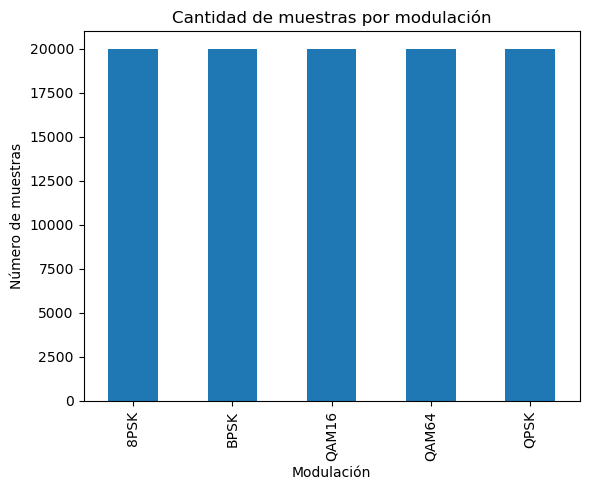

In [10]:
class_counts.plot(kind="bar")
plt.title("Cantidad de muestras por modulación")
plt.xlabel("Modulación")
plt.ylabel("Número de muestras")
plt.show()

### Distribución por SNR

In [11]:
snr_counts = df_selected.groupby("snr")["num_samples"].sum()
print(snr_counts)

snr
-20    5000
-18    5000
-16    5000
-14    5000
-12    5000
-10    5000
-8     5000
-6     5000
-4     5000
-2     5000
 0     5000
 2     5000
 4     5000
 6     5000
 8     5000
 10    5000
 12    5000
 14    5000
 16    5000
 18    5000
Name: num_samples, dtype: int64


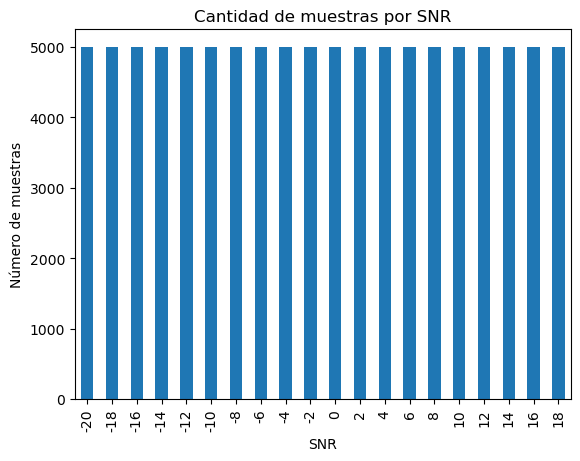

In [12]:
snr_counts.plot(kind="bar")
plt.title("Cantidad de muestras por SNR")
plt.xlabel("SNR")
plt.ylabel("Número de muestras")
plt.show()

### Distribución cruzada modulación-SNR

In [13]:
pivot = df_selected.pivot_table(
    values="num_samples",
    index="modulation",
    columns="snr",
    aggfunc="sum"
)

pivot

snr,-20,-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18
modulation,,,,,,,,,,,,,,,,,,,,
8PSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
BPSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QAM16,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QAM64,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QPSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000


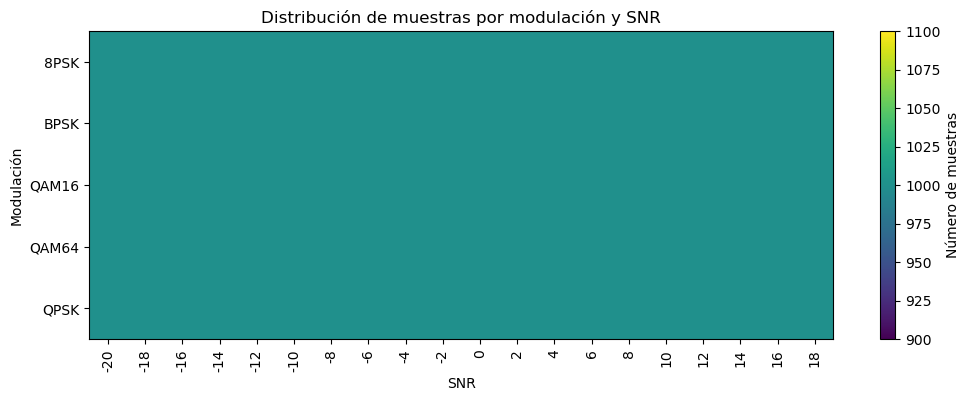

In [14]:
plt.figure(figsize=(12, 4))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Número de muestras")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Distribución de muestras por modulación y SNR")
plt.xlabel("SNR")
plt.ylabel("Modulación")
plt.show()

### Construir dataset final X, y, SNR

In [15]:
X = []
y = []
snr_values = []

for (mod, snr), samples in data.items():
    if mod in selected_mods:
        X.append(samples)
        y.extend([mod] * samples.shape[0])
        snr_values.extend([snr] * samples.shape[0])

X = np.vstack(X)
y = np.array(y)
snr_values = np.array(snr_values)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("snr shape:", snr_values.shape)

X shape: (100000, 2, 128)
y shape: (100000,)
snr shape: (100000,)


In [16]:
X_flat = X.reshape(X.shape[0], -1)

print("X para MLP:", X_flat.shape)

X para MLP: (100000, 256)


### Faltantes, infinitos o anómalos

In [17]:
print("NaN:", np.isnan(X).sum())
print("Inf:", np.isinf(X).sum())

print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Media:", X.mean())
print("Desviación estándar:", X.std())


NaN: 0
Inf: 0
Valor mínimo: -0.15494554
Valor máximo: 0.16422912
Media: -4.7892547e-05
Desviación estándar: 0.0060583474


### Señales IQ en el tiempo

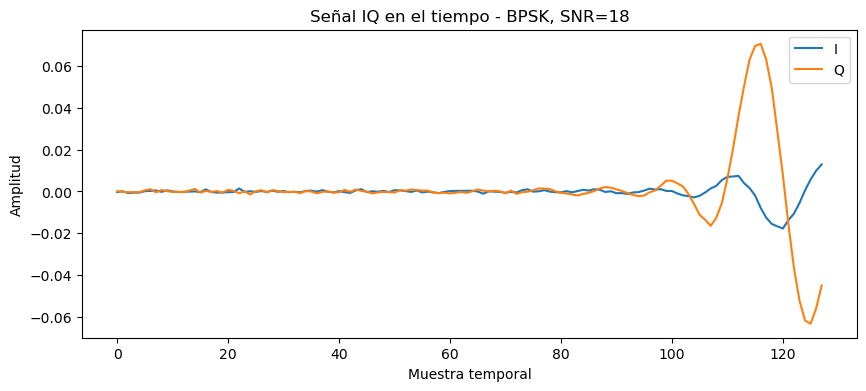

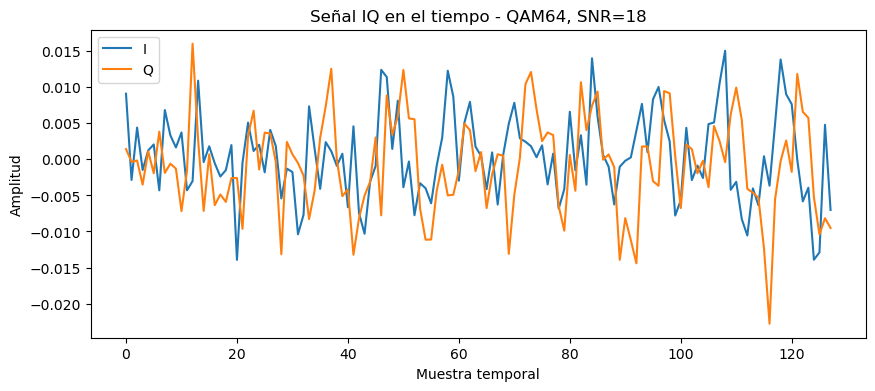

In [18]:
def plot_iq_signal(X, y, snr_values, modulation, snr, index=0):
    idx = np.where((y == modulation) & (snr_values == snr))[0]
    sample = X[idx[index]]
    
    I = sample[0]
    Q = sample[1]
    
    plt.figure(figsize=(10, 4))
    plt.plot(I, label="I")
    plt.plot(Q, label="Q")
    plt.title(f"Señal IQ en el tiempo - {modulation}, SNR={snr}")
    plt.xlabel("Muestra temporal")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.show()

plot_iq_signal(X, y, snr_values, "BPSK", 18)
plot_iq_signal(X, y, snr_values, "QAM64", 18)

### Constelaciones

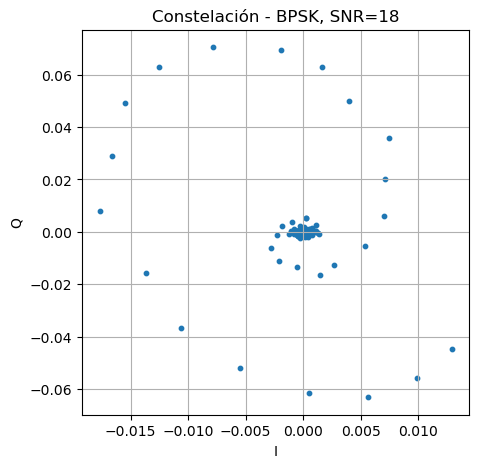

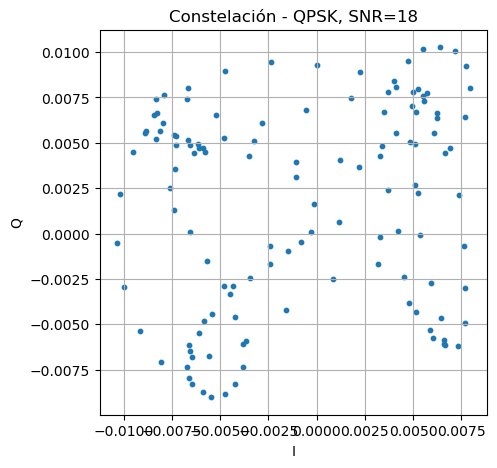

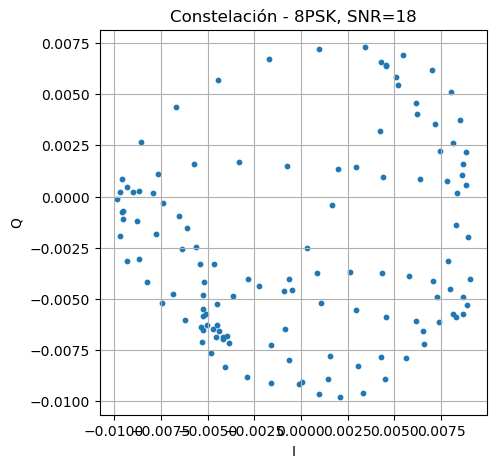

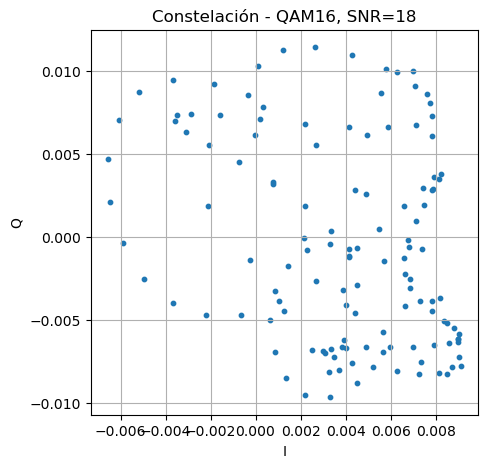

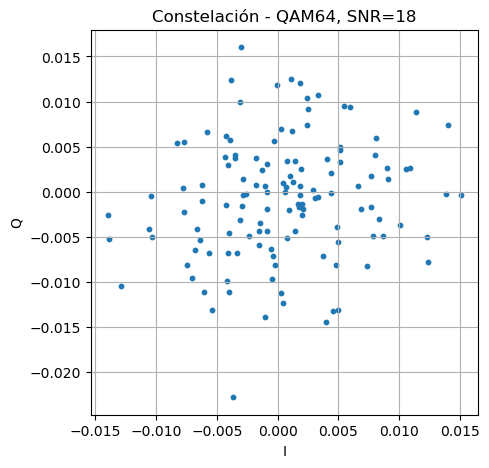

In [19]:
def plot_constellation(X, y, snr_values, modulation, snr, index=0):
    idx = np.where((y == modulation) & (snr_values == snr))[0]
    sample = X[idx[index]]
    
    I = sample[0]
    Q = sample[1]
    
    plt.figure(figsize=(5, 5))
    plt.scatter(I, Q, s=10)
    plt.title(f"Constelación - {modulation}, SNR={snr}")
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.grid(True)
    plt.show()

for mod in selected_mods:
    plot_constellation(X, y, snr_values, mod, 18)


In [20]:
def compare_constellation_snr(X, y, snr_values, modulation, snr_high=18, snr_low=-10, index=0):
    # Índices para SNR alto
    idx_high = np.where((y == modulation) & (snr_values == snr_high))[0]
    sample_high = X[idx_high[index]]
    
    I_high = sample_high[0]
    Q_high = sample_high[1]
    
    # Índices para SNR bajo
    idx_low = np.where((y == modulation) & (snr_values == snr_low))[0]
    sample_low = X[idx_low[index]]
    
    I_low = sample_low[0]
    Q_low = sample_low[1]
    
    # Gráficas comparativas
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].scatter(I_high, Q_high, s=10)
    axes[0].set_title(f"{modulation}, SNR={snr_high}")
    axes[0].set_xlabel("I")
    axes[0].set_ylabel("Q")
    axes[0].grid(True)
    axes[0].axis("equal")
    
    axes[1].scatter(I_low, Q_low, s=10)
    axes[1].set_title(f"{modulation}, SNR={snr_low}")
    axes[1].set_xlabel("I")
    axes[1].set_ylabel("Q")
    axes[1].grid(True)
    axes[1].axis("equal")
    
    plt.suptitle(f"Comparación de constelaciones para {modulation}")
    plt.show()

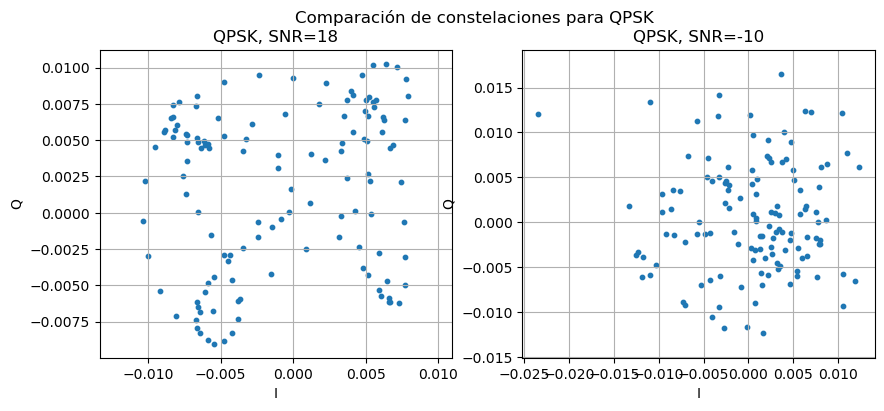

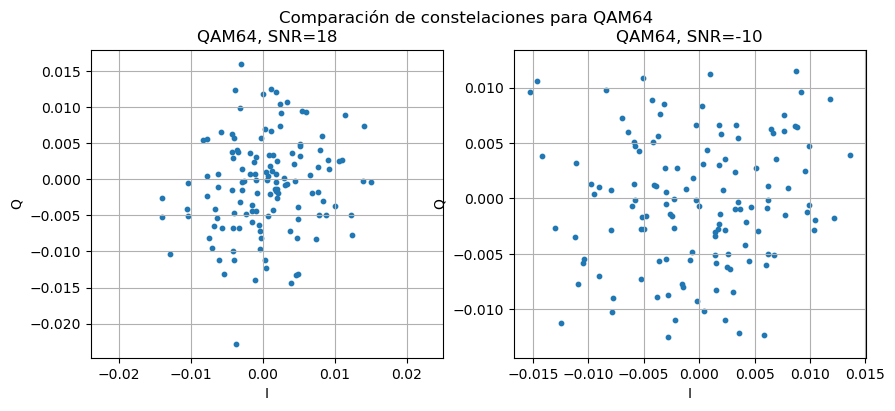

In [21]:
compare_constellation_snr(X, y, snr_values, "QPSK", 18, -10)
compare_constellation_snr(X, y, snr_values, "QAM64", 18, -10)

### Analizar amplitud y fase

In [22]:
I = X[:, 0, :]
Q = X[:, 1, :]

amplitude = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)

print("Amplitude shape:", amplitude.shape)
print("Phase shape:", phase.shape)

Amplitude shape: (100000, 128)
Phase shape: (100000, 128)


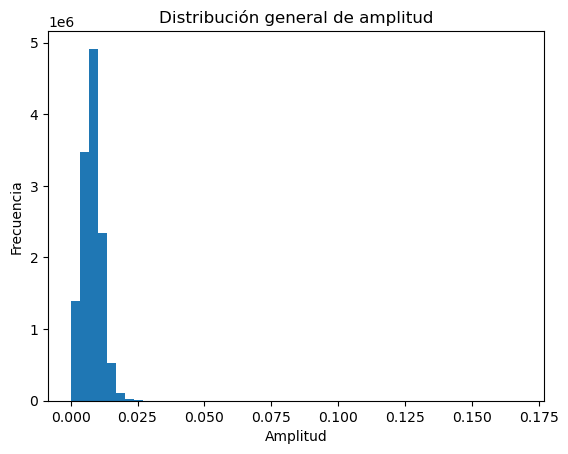

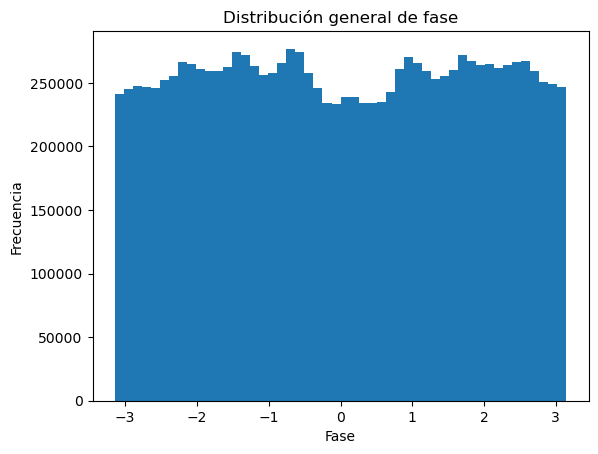

In [23]:
plt.hist(amplitude.flatten(), bins=50)
plt.title("Distribución general de amplitud")
plt.xlabel("Amplitud")
plt.ylabel("Frecuencia")
plt.show()

plt.hist(phase.flatten(), bins=50)
plt.title("Distribución general de fase")
plt.xlabel("Fase")
plt.ylabel("Frecuencia")
plt.show()

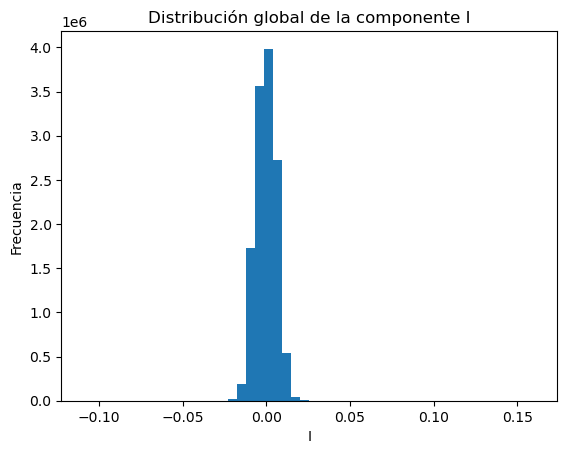

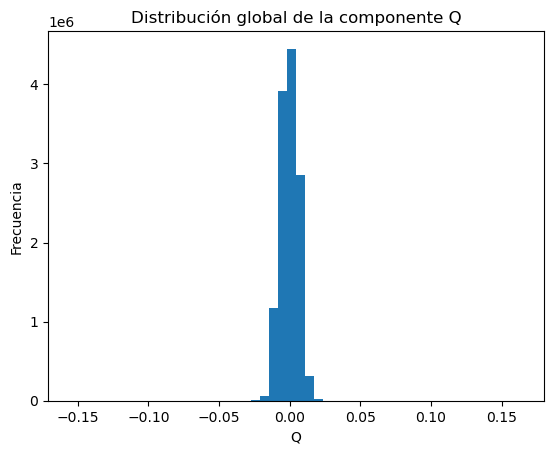

In [24]:
# Distribución global de I y Q
I = X[:, 0, :]
Q = X[:, 1, :]

plt.hist(I.flatten(), bins=50)
plt.title("Distribución global de la componente I")
plt.xlabel("I")
plt.ylabel("Frecuencia")
plt.show()

plt.hist(Q.flatten(), bins=50)
plt.title("Distribución global de la componente Q")
plt.xlabel("Q")
plt.ylabel("Frecuencia")
plt.show()

### Potencia promedio por modulación

In [25]:
power = np.mean(I**2 + Q**2, axis=1)

df_features = pd.DataFrame({
    "modulation": y,
    "snr": snr_values,
    "power": power
})

df_features.groupby("modulation")["power"].describe()

,count,mean,std,min,25%,50%,75%,max
modulation,,,,,,,,
8PSK,20000.0,0.000072,0.000009,0.000062,0.000066,0.000073,0.000078,0.000491
BPSK,20000.0,0.000074,0.000007,0.000063,0.000070,0.000074,0.000078,0.000533
QAM16,20000.0,0.000074,0.000009,0.000064,0.000070,0.000073,0.000077,0.000647
QAM64,20000.0,0.000074,0.000011,0.000064,0.000071,0.000073,0.000076,0.000519
QPSK,20000.0,0.000072,0.000009,0.000062,0.000066,0.000073,0.000078,0.000477


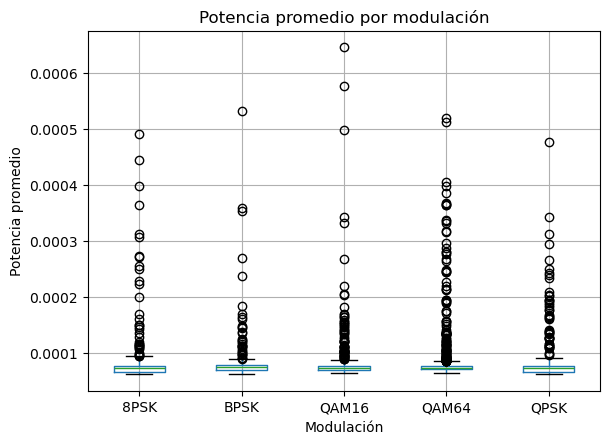

In [26]:
df_features.boxplot(column="power", by="modulation")
plt.title("Potencia promedio por modulación")
plt.suptitle("")
plt.xlabel("Modulación")
plt.ylabel("Potencia promedio")
plt.show()

### Características derivadas de la señal IQ

In [27]:
# Características derivadas para análisis exploratorio

I = X[:, 0, :]
Q = X[:, 1, :]

amplitude = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)
power_inst = I**2 + Q**2

phase_sin = np.sin(phase)
phase_cos = np.cos(phase)

df_eda_features = pd.DataFrame({
    "modulation": y,
    "snr": snr_values,
    "amplitude_mean": amplitude.mean(axis=1),
    "amplitude_std": amplitude.std(axis=1),
    "power_mean": power_inst.mean(axis=1),
    "power_std": power_inst.std(axis=1),
    "phase_sin_mean": phase_sin.mean(axis=1),
    "phase_cos_mean": phase_cos.mean(axis=1)
})

df_eda_features.head()

,modulation,snr,amplitude_mean,amplitude_std,power_mean,power_std,phase_sin_mean,phase_cos_mean
0,QPSK,2,0.007812,0.002740,0.000069,0.000042,0.076101,-0.023114
1,QPSK,2,0.007812,0.002668,0.000068,0.000043,0.059835,0.089493
2,QPSK,2,0.007812,0.002873,0.000069,0.000047,0.056260,0.070240
3,QPSK,2,0.007812,0.002991,0.000070,0.000049,0.031913,0.035141
4,QPSK,2,0.007813,0.002578,0.000068,0.000041,-0.157287,0.172426


In [28]:
df_eda_features.groupby("modulation")[
    ["amplitude_mean", "amplitude_std", "power_mean", "power_std", "phase_sin_mean", "phase_cos_mean"]
].mean()

,amplitude_mean,amplitude_std,power_mean,power_std,phase_sin_mean,phase_cos_mean
modulation,,,,,,
8PSK,0.007812,0.003220,0.000072,0.000057,-0.003972,-0.006388
BPSK,0.007812,0.003577,0.000074,0.000062,-0.002561,-0.006067
QAM16,0.007812,0.003515,0.000074,0.000061,-0.003757,-0.004369
QAM64,0.007812,0.003523,0.000074,0.000062,-0.000347,-0.004483
QPSK,0.007812,0.003221,0.000072,0.000057,-0.001751,-0.005619


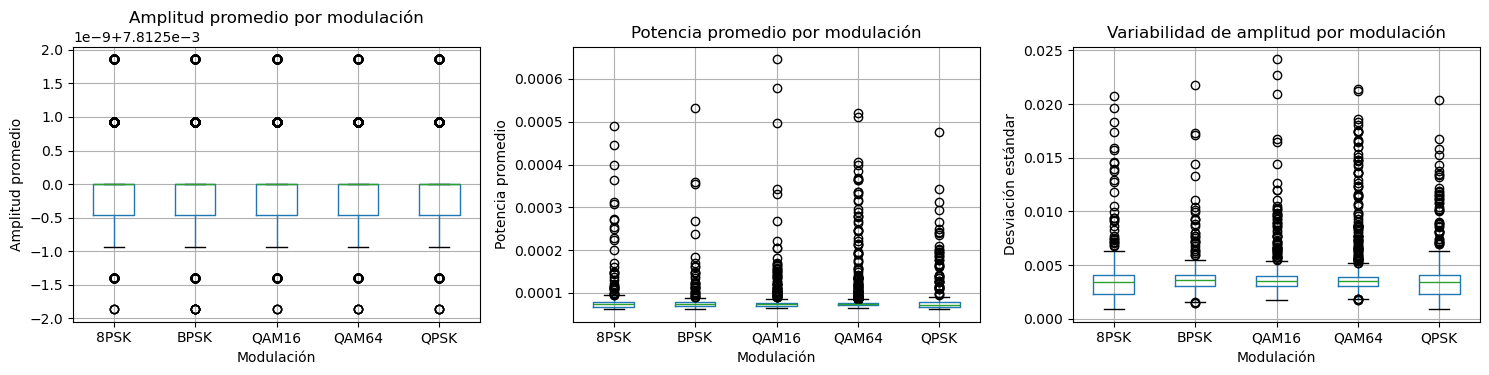

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_eda_features.boxplot(column="amplitude_mean", by="modulation", ax=axes[0])
axes[0].set_title("Amplitud promedio por modulación")
axes[0].set_xlabel("Modulación")
axes[0].set_ylabel("Amplitud promedio")

df_eda_features.boxplot(column="power_mean", by="modulation", ax=axes[1])
axes[1].set_title("Potencia promedio por modulación")
axes[1].set_xlabel("Modulación")
axes[1].set_ylabel("Potencia promedio")

df_eda_features.boxplot(column="amplitude_std", by="modulation", ax=axes[2])
axes[2].set_title("Variabilidad de amplitud por modulación")
axes[2].set_xlabel("Modulación")
axes[2].set_ylabel("Desviación estándar")

plt.suptitle("")
plt.tight_layout()
plt.show()



En esta sección se analiza el promedio de `phase_sin` y `phase_cos` por modulación para observar si la información angular presenta diferencias entre clases.

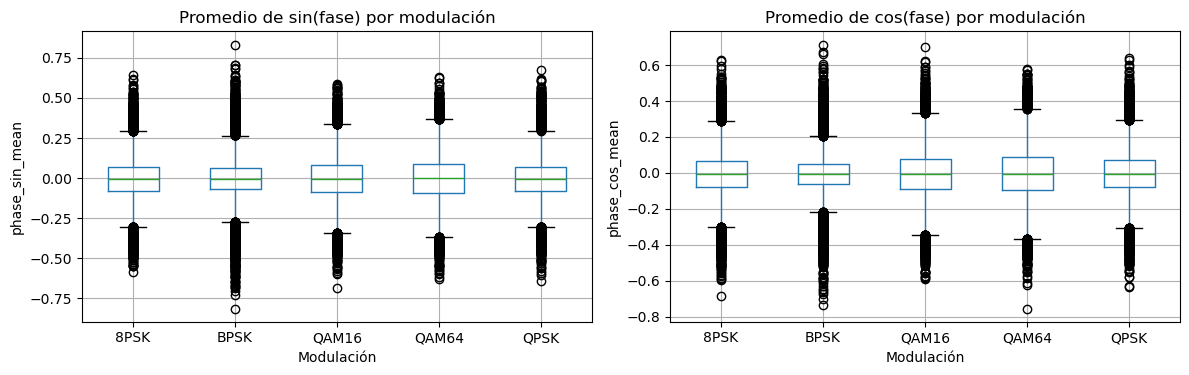

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_eda_features.boxplot(
    column="phase_sin_mean",
    by="modulation",
    ax=axes[0]
)
axes[0].set_title("Promedio de sin(fase) por modulación")
axes[0].set_xlabel("Modulación")
axes[0].set_ylabel("phase_sin_mean")

df_eda_features.boxplot(
    column="phase_cos_mean",
    by="modulation",
    ax=axes[1]
)
axes[1].set_title("Promedio de cos(fase) por modulación")
axes[1].set_xlabel("Modulación")
axes[1].set_ylabel("phase_cos_mean")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [63]:
df_eda_features.groupby("modulation")[
    ["phase_sin_mean", "phase_cos_mean"]
].describe()

phase_sin_mean                                                    \
                    count      mean       std       min       25%       50%   
modulation                                                                    
8PSK              20000.0 -0.003972  0.135998 -0.583302 -0.078652 -0.005483   
BPSK              20000.0 -0.002561  0.140145 -0.813846 -0.070969 -0.003598   
QAM16             20000.0 -0.003757  0.145371 -0.683845 -0.087942 -0.004776   
QAM64             20000.0 -0.000347  0.151668 -0.628615 -0.092661 -0.002026   
QPSK              20000.0 -0.001751  0.135817 -0.643193 -0.078582 -0.004396   

                               phase_cos_mean                                \
                 75%       max          count      mean       std       min   
modulation                                                                    
8PSK        0.070555  0.641775        20000.0 -0.006388  0.135593 -0.685513   
BPSK        0.063751  0.833489        20000.0 -0.006067  0.114532 -0.732771   
QAM16       0.081928  0.590192        20000.0 -0.004369  0.144825 -0.591448   
QAM64       0.090753  0.632403        20000.0 -0.004483  0.150530 -0.754776   
QPSK        0.071539  0.672348        20000.0 -0.005619  0.134423 -0.632508   

                                                    
                 25%       50%       75%       max  
modulation                                          
8PSK       -0.080180 -0.007070  0.067816  0.627019  
BPSK       -0.059626 -0.006016  0.047056  0.714521  
QAM16      -0.089508 -0.005437  0.079925  0.702308  
QAM64      -0.094963 -0.005266  0.086217  0.578037  
QPSK       -0.080903 -0.006749  0.069381  0.638857

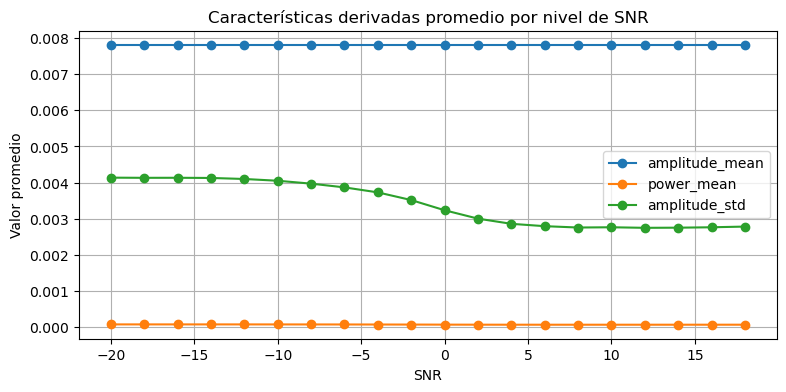

In [31]:
snr_feature_summary = df_eda_features.groupby("snr")[
    ["amplitude_mean", "power_mean", "amplitude_std"]
].mean()

snr_feature_summary.plot(figsize=(9, 4), marker="o")
plt.title("Características derivadas promedio por nivel de SNR")
plt.xlabel("SNR")
plt.ylabel("Valor promedio")
plt.grid(True)
plt.show()

### Interpretación del EDA

El análisis exploratorio permitió comprender la estructura del dataset RML2016.10A y justificar las decisiones de modelado. El conjunto de datos se encuentra balanceado por tipo de modulación y por nivel de SNR, lo cual permite comparar los modelos de forma justa y utilizar accuracy como métrica principal sin que una clase tenga mayor influencia que las demás.

Cada señal está representada por dos componentes, I y Q, con 128 muestras temporales por canal. Al observar las señales en el tiempo y las constelaciones, se evidencia que las modulaciones presentan patrones diferenciables; sin embargo, también existe superposición entre clases, especialmente cuando el SNR es bajo. Esto indica que el ruido afecta directamente la separabilidad de las modulaciones.

El EDA también muestra que variables simples como la potencia promedio no son suficientes para separar completamente las clases. Por esta razón, se justifica realizar Feature Extraction a partir de las señales IQ, generando características derivadas como amplitud, potencia y fase circular. El EDA muestra que variables simples como la potencia promedio o la amplitud promedio no son suficientes para separar completamente las clases, ya que sus distribuciones se superponen entre modulaciones. Sin embargo, estas características sí aportan información complementaria sobre la magnitud, energía y variabilidad de la señal. Por esta razón, se justifica realizar Feature Extraction a partir de las señales IQ, combinando las muestras IQ crudas con amplitud, potencia, fase circular y estadísticas resumen para construir una representación más informativa para los modelos de machine learning.


## Feature Extraction

En esta versión se realiza Feature Extraction a partir de las señales IQ crudas. Aunque las componentes I y Q contienen la información original de la señal, se generan variables derivadas con significado físico, como amplitud, potencia y representación circular de la fase.

La amplitud se calcula como la magnitud de la señal compleja, la potencia como la energía instantánea normalizada, y la fase se representa mediante seno y coseno para evitar problemas de discontinuidad angular. Estas características se concatenan con las muestras IQ originales, con el objetivo de proporcionar al modelo MLP una representación más rica de la señal.

La extracción de características se realiza después de dividir el conjunto en entrenamiento y prueba, aplicando la misma función de transformación a ambos conjuntos.

In [32]:
def crear_features_iq(X_flat_input):
    """
    Crea características derivadas a partir de señales IQ aplanadas.

    Entrada:
        X_flat_input: matriz con forma (n_muestras, 256)
                      donde cada fila contiene I0...I127, Q0...Q127.

    Salida:
        X_features: matriz con IQ crudo + amplitud + potencia + fase circular + estadísticas.
    """

    X_iq = X_flat_input.reshape(X_flat_input.shape[0], 2, -1)

    I = X_iq[:, 0, :]
    Q = X_iq[:, 1, :]

    amplitude = np.sqrt(I**2 + Q**2)
    power = I**2 + Q**2

    phase = np.arctan2(Q, I)
    phase_sin = np.sin(phase)
    phase_cos = np.cos(phase)

    stats = np.column_stack([
        I.mean(axis=1),
        I.std(axis=1),
        Q.mean(axis=1),
        Q.std(axis=1),

        amplitude.mean(axis=1),
        amplitude.std(axis=1),
        amplitude.max(axis=1),
        amplitude.min(axis=1),

        power.mean(axis=1),
        power.std(axis=1),
        power.max(axis=1),
        power.min(axis=1),

        phase_sin.mean(axis=1),
        phase_sin.std(axis=1),
        phase_cos.mean(axis=1),
        phase_cos.std(axis=1)
    ])

    X_features = np.hstack([
        X_flat_input,
        amplitude,
        power,
        phase_sin,
        phase_cos,
        stats
    ])

    return X_features

## Preparación para modelado

Después del EDA, se prepara el conjunto de datos para los modelos de machine learning. Primero, cada señal IQ de forma \(2 \times 128\) se aplana en un vector de 256 valores. Posteriormente, se generan características derivadas de amplitud, potencia y fase circular, aumentando la representación final a 784 características por señal.

Las etiquetas de modulación se codifican numéricamente y el dataset se divide en entrenamiento y prueba. La división se realiza de forma estratificada combinando modulación y SNR, con el objetivo de conservar en ambos conjuntos una distribución equilibrada de clases y niveles de ruido.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Aplanar señales IQ 
X_flat = X.reshape(X.shape[0], -1)

print("Forma original de X:", X.shape)
print("Forma aplanada de X:", X_flat.shape)

Forma original de X: (100000, 2, 128)
Forma aplanada de X: (100000, 256)


In [34]:
# Codificar etiquetas de modulación
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Clases originales:", label_encoder.classes_)
print("Primeras etiquetas codificadas:", y_encoded[:10])

Clases originales: ['8PSK' 'BPSK' 'QAM16' 'QAM64' 'QPSK']
Primeras etiquetas codificadas: [4 4 4 4 4 4 4 4 4 4]


In [35]:
# Estratificación combinando modulación y SNR
stratify_key = np.array([f"{mod}_{snr}" for mod, snr in zip(y, snr_values)])

X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(
    X_flat,
    y_encoded,
    snr_values,
    test_size=0.2,
    random_state=42,
    stratify=stratify_key
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("snr_train:", snr_train.shape)
print("snr_test:", snr_test.shape)

X_train: (80000, 256)
X_test: (20000, 256)
y_train: (80000,)
y_test: (20000,)
snr_train: (80000,)
snr_test: (20000,)


In [36]:
# Guardar versión IQ cruda aplanada
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# Crear versión mejorada con características derivadas
X_train = crear_features_iq(X_train_raw)
X_test = crear_features_iq(X_test_raw)

print("X_train crudo:", X_train_raw.shape)
print("X_test crudo:", X_test_raw.shape)

print("X_train con features:", X_train.shape)
print("X_test con features:", X_test.shape)

X_train crudo: (80000, 256)
X_test crudo: (20000, 256)
X_train con features: (80000, 784)
X_test con features: (20000, 784)


## Pipelines y Feature Selection

Se utilizan pipelines para integrar el preprocesamiento, la selección de características y el entrenamiento de los modelos en un único flujo de trabajo.

Cada pipeline incluye:

1. `StandardScaler`: estandariza las variables de entrada.
2. `SelectKBest`: aplica selección de características tipo filtro.
3. Modelo de clasificación: MLP o Regresión Logística L2.

La selección de características se realiza con `SelectKBest` y `f_classif`. Esta técnica evalúa la relación estadística entre cada característica y la clase objetivo, seleccionando las variables más relevantes. Al incluirla dentro del pipeline, se evita fuga de información, ya que la selección se ajusta únicamente con los datos de entrenamiento durante cada partición de validación cruzada.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Pipeline MLP

##### Modelo principal: Red Neuronal MLP

El modelo principal es una red neuronal MLP. En esta versión, la MLP recibe una representación ampliada de cada señal IQ, compuesta por las muestras I/Q originales y características derivadas como amplitud, potencia y fase representada mediante seno y coseno. Esta representación busca proporcionar al modelo información física adicional de la señal.

In [38]:
pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(score_func=f_classif, k=192)),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        alpha=0.01,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.20,
        n_iter_no_change=10,
        random_state=42
    ))
])

pipeline_mlp

,steps,"[('scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,score_func,<function f_c...00264DF1B6D40>
,k,192
,hidden_layer_sizes,"(256, ...)"
,activation,'relu'


## Pipeline Regresión Logística L2

#### Modelo base: Regresión Logística con regularización L2

Como modelo base se utiliza Regresión Logística con regularización L2. Este modelo es un clasificador lineal regularizado y permite comparar si la MLP, al ser un modelo no lineal, logra mejorar el desempeño frente a una técnica más simple.

La regularización L2 penaliza pesos excesivamente grandes, ayudando a reducir el sobreajuste. En este modelo, el hiperparámetro principal es \(C\), que controla la fuerza de regularización. Valores pequeños de \(C\) implican mayor regularización, mientras que valores grandes reducen la penalización.

In [39]:
pipeline_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(score_func=f_classif, k=256)),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=1000
    ))
])

pipeline_logreg

,steps,"[('scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,score_func,<function f_c...00264DF1B6D40>
,k,256
,penalty,'l2'
,dual,False


## Entrenamiento inicial de ambos modelos

#### Entrenamiento inicial de ambos modelos

Antes de optimizar hiperparámetros, se entrenan versiones iniciales de la MLP y de la Regresión Logística L2. Esto permite obtener una primera línea base de desempeño para comparar cómo se comportan ambos modelos sin ajuste fino.

In [40]:
def evaluar_modelo(modelo, X_test, y_test, nombre_modelo):
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy {nombre_modelo}: {acc:.4f}")
    print()
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))
    
    cm = confusion_matrix(y_test, y_pred)
    
    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()
    
    return y_pred, acc

Accuracy MLP inicial: 0.4392

              precision    recall  f1-score   support

        8PSK       0.34      0.37      0.35      4000
        BPSK       0.60      0.62      0.61      4000
       QAM16       0.38      0.31      0.34      4000
       QAM64       0.50      0.47      0.49      4000
        QPSK       0.38      0.42      0.40      4000

    accuracy                           0.44     20000
   macro avg       0.44      0.44      0.44     20000
weighted avg       0.44      0.44      0.44     20000



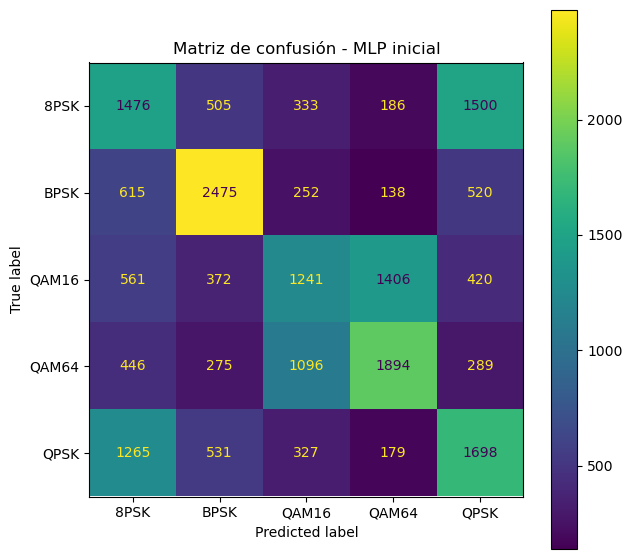

In [41]:
# Entrenamiento inicial MLP
pipeline_mlp.fit(X_train, y_train)

y_pred_mlp_initial, accuracy_mlp_initial = evaluar_modelo(
    pipeline_mlp,
    X_test,
    y_test,
    "MLP inicial"
)

Accuracy Regresión Logística L2 inicial: 0.3436

              precision    recall  f1-score   support

        8PSK       0.33      0.30      0.31      4000
        BPSK       0.48      0.45      0.47      4000
       QAM16       0.29      0.28      0.28      4000
       QAM64       0.29      0.33      0.31      4000
        QPSK       0.34      0.36      0.35      4000

    accuracy                           0.34     20000
   macro avg       0.35      0.34      0.34     20000
weighted avg       0.35      0.34      0.34     20000



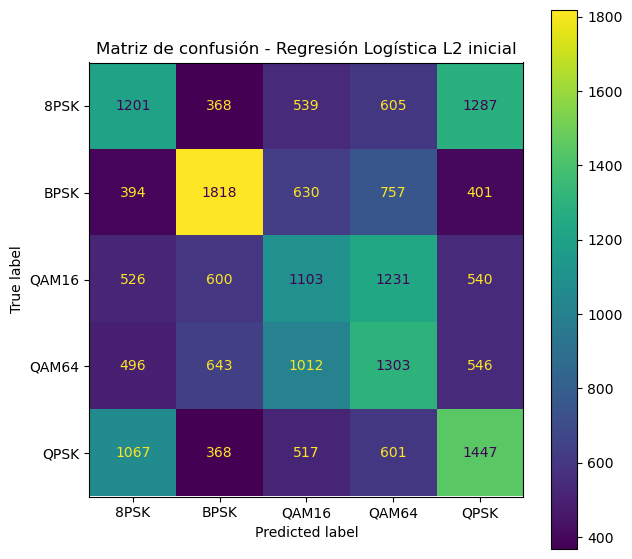

In [42]:
# Entrenamiento inicial Regresión Logística L2
pipeline_logreg.fit(X_train, y_train)

y_pred_logreg_initial, accuracy_logreg_initial = evaluar_modelo(
    pipeline_logreg,
    X_test,
    y_test,
    "Regresión Logística L2 inicial"
)

#### Optimización de hiperparámetros

La optimización de hiperparámetros se realiza mediante `GridSearchCV` y `RepeatedStratifiedKFold`. Debido al tamaño del dataset y al costo computacional de entrenar múltiples modelos, se utiliza una muestra estratificada del conjunto de entrenamiento definida por `OPT_SIZE = 40000`.

La estratificación se realiza combinando la etiqueta de modulación y el nivel de SNR, con el objetivo de conservar en cada partición una distribución equilibrada de clases y niveles de ruido. Se emplean 5 folds y 2 repeticiones, obteniendo un total de 10 evaluaciones por combinación de hiperparámetros.

En la MLP se optimizan el número de características seleccionadas mediante `SelectKBest`, la arquitectura de capas ocultas, la regularización L2 mediante `alpha` y la tasa de aprendizaje inicial. En la Regresión Logística L2 se optimizan el número de características seleccionadas y el parámetro `C`, que controla la fuerza de regularización.

Esta estrategia permite comparar modelos optimizados bajo un mismo esquema de validación cruzada, evitando comparar un modelo ajustado contra otro sin optimización.


In [43]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

# Muestra para optimización

OPT_SIZE = 40000

stratify_train_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_train, snr_train)
])

X_train_opt, _, y_train_opt, _, snr_train_opt, _ = train_test_split(
    X_train,
    y_train,
    snr_train,
    train_size=OPT_SIZE,
    random_state=42,
    stratify=stratify_train_key
)

print("X_train_opt:", X_train_opt.shape)
print("y_train_opt:", y_train_opt.shape)
print("snr_train_opt:", snr_train_opt.shape)

X_train_opt: (40000, 784)
y_train_opt: (40000,)
snr_train_opt: (40000,)


In [44]:
cv_opt = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)

stratify_cv_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_train_opt, snr_train_opt)
])

cv_splits_opt = list(cv_opt.split(X_train_opt, stratify_cv_key))

print("Número de folds:", len(cv_splits_opt))

Número de folds: 10


## Optimizar MLP

In [45]:

param_grid_mlp = {
    "feature_selection__k": [128, 192, 256],

    "mlp__hidden_layer_sizes": [
        (128, 64),
        (256, 128)
    ],

    "mlp__alpha": [
        0.003,
        0.01,
        0.03
    ],

    "mlp__learning_rate_init": [
        0.001,
        0.0005
    ]
}


grid_search_mlp = GridSearchCV(
    estimator=pipeline_mlp,
    param_grid=param_grid_mlp,
    scoring="accuracy",
    cv=cv_splits_opt,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search_mlp.fit(X_train_opt, y_train_opt)

print("Mejores hiperparámetros MLP:")
print(grid_search_mlp.best_params_)

print("Mejor accuracy promedio en CV:")
print(grid_search_mlp.best_score_)



Fitting 10 folds for each of 36 candidates, totalling 360 fits
Mejores hiperparámetros MLP:
{'feature_selection__k': 256, 'mlp__alpha': 0.03, 'mlp__hidden_layer_sizes': (256, 128), 'mlp__learning_rate_init': 0.001}
Mejor accuracy promedio en CV:
0.404


## Optimizar Regresión Logística L2

In [46]:

import gc

gc.collect()

param_grid_logreg = {
    "feature_selection__k": [256, 384],
    "logreg__C": [0.01, 0.1, 1, 10]
}

grid_search_logreg = GridSearchCV(
    estimator=pipeline_logreg,
    param_grid=param_grid_logreg,
    scoring="accuracy",
    cv=cv_splits_opt,
    n_jobs=1,
    verbose=2,
    return_train_score=True,
    pre_dispatch=1
)

grid_search_logreg.fit(X_train_opt, y_train_opt)

print("Mejores hiperparámetros Regresión Logística L2:")
print(grid_search_logreg.best_params_)

print("Mejor accuracy promedio en CV:")
print(grid_search_logreg.best_score_)

Fitting 10 folds for each of 8 candidates, totalling 80 fits
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.4s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.3s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.2s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.0s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.2s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.2s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.1s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.0s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.2s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.3s
[CV] END ............feature_selection__k=256, logreg__C=0.1; total time=   5.2s
[CV] END ............feature_selection__k=256, l

## Gráficas de optimización de hiperparámetros

Se grafica el error promedio de entrenamiento y validación cruzada frente a un hiperparámetro del modelo.

En la MLP se analiza el parámetro `alpha`, que corresponde a la regularización L2 interna del modelo. Valores muy bajos de regularización pueden favorecer sobreajuste, mientras que valores muy altos pueden generar subajuste.

En la Regresión Logística L2 se analiza el parámetro \(C\). Este parámetro es inverso a la fuerza de regularización: valores pequeños de \(C\) aplican mayor regularización, mientras que valores grandes aplican menor regularización.

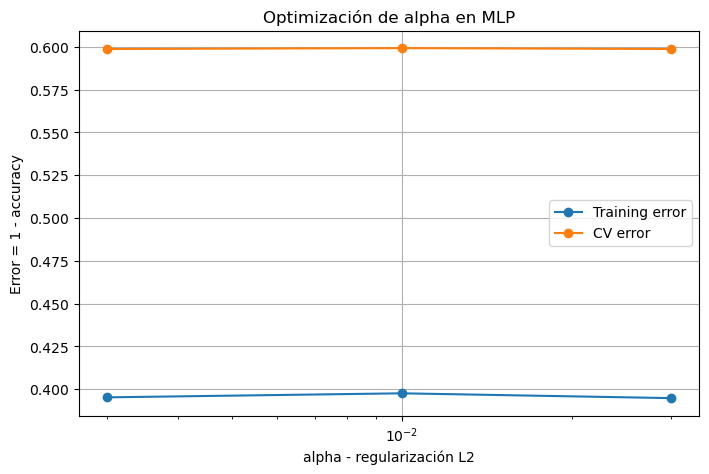

,param_mlp__alpha,mean_train_score,mean_test_score,train_error,cv_error
0,0.003,0.604804,0.401270,0.395196,0.598730
1,0.010,0.602445,0.400740,0.397555,0.599260
2,0.030,0.605259,0.401271,0.394741,0.598729


In [47]:
results_mlp = pd.DataFrame(grid_search_mlp.cv_results_)

# Agrupar resultados por alpha
mlp_alpha_curve = results_mlp.groupby("param_mlp__alpha").agg({
    "mean_train_score": "mean",
    "mean_test_score": "mean"
}).reset_index()

mlp_alpha_curve["train_error"] = 1 - mlp_alpha_curve["mean_train_score"]
mlp_alpha_curve["cv_error"] = 1 - mlp_alpha_curve["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(
    mlp_alpha_curve["param_mlp__alpha"],
    mlp_alpha_curve["train_error"],
    marker="o",
    label="Training error"
)
plt.plot(
    mlp_alpha_curve["param_mlp__alpha"],
    mlp_alpha_curve["cv_error"],
    marker="o",
    label="CV error"
)

plt.xscale("log")
plt.title("Optimización de alpha en MLP")
plt.xlabel("alpha - regularización L2")
plt.ylabel("Error = 1 - accuracy")
plt.legend()
plt.grid(True)
plt.show()

mlp_alpha_curve

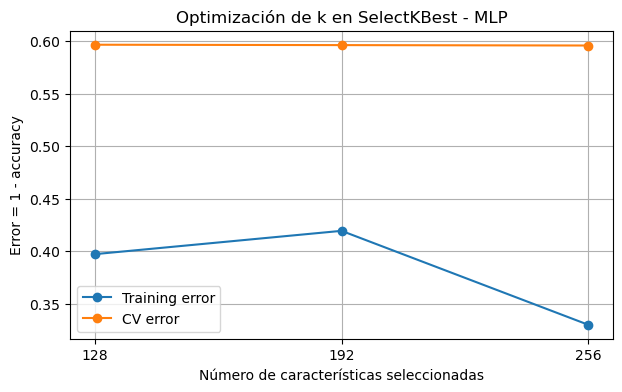

,param_feature_selection__k,mean_train_score,mean_test_score,train_error,cv_error
10,128,0.602641,0.403250,0.397359,0.596750
12,192,0.580456,0.403613,0.419544,0.596387
34,256,0.669847,0.404000,0.330153,0.596000


In [48]:
results_mlp["k_label"] = results_mlp["param_feature_selection__k"].astype(str)

idx_best_k = results_mlp.groupby("k_label")["mean_test_score"].idxmax()
best_by_k = results_mlp.loc[idx_best_k].copy()

best_by_k["cv_error"] = 1 - best_by_k["mean_test_score"]
best_by_k["train_error"] = 1 - best_by_k["mean_train_score"]

# Orden automático de k
def ordenar_k(valor):
    if valor == "all":
        return 999999
    return int(valor)

best_by_k["k_order"] = best_by_k["k_label"].apply(ordenar_k)
best_by_k = best_by_k.sort_values("k_order")

plt.figure(figsize=(7, 4))
plt.plot(
    best_by_k["k_label"].astype(str),
    best_by_k["train_error"],
    marker="o",
    label="Training error"
)
plt.plot(
    best_by_k["k_label"].astype(str),
    best_by_k["cv_error"],
    marker="o",
    label="CV error"
)

plt.title("Optimización de k en SelectKBest - MLP")
plt.xlabel("Número de características seleccionadas")
plt.ylabel("Error = 1 - accuracy")
plt.legend()
plt.grid(True)
plt.show()

best_by_k[[
    "param_feature_selection__k",
    "mean_train_score",
    "mean_test_score",
    "train_error",
    "cv_error"
]]

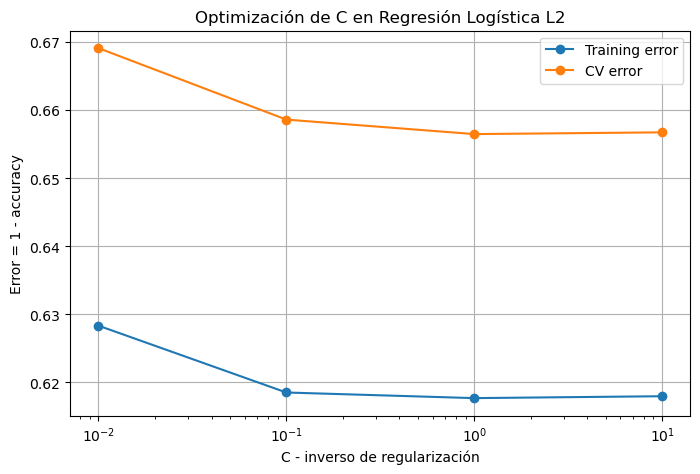

,param_logreg__C,mean_train_score,mean_test_score,train_error,cv_error
0,0.01,0.371661,0.330863,0.628339,0.669137
1,0.10,0.381486,0.341369,0.618514,0.658631
2,1.00,0.382312,0.343500,0.617687,0.656500
3,10.00,0.382033,0.343244,0.617967,0.656756


In [49]:
results_logreg = pd.DataFrame(grid_search_logreg.cv_results_)

# Agrupar resultados por C
logreg_c_curve = results_logreg.groupby("param_logreg__C").agg({
    "mean_train_score": "mean",
    "mean_test_score": "mean"
}).reset_index()

logreg_c_curve["train_error"] = 1 - logreg_c_curve["mean_train_score"]
logreg_c_curve["cv_error"] = 1 - logreg_c_curve["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(
    logreg_c_curve["param_logreg__C"],
    logreg_c_curve["train_error"],
    marker="o",
    label="Training error"
)
plt.plot(
    logreg_c_curve["param_logreg__C"],
    logreg_c_curve["cv_error"],
    marker="o",
    label="CV error"
)

plt.xscale("log")
plt.title("Optimización de C en Regresión Logística L2")
plt.xlabel("C - inverso de regularización")
plt.ylabel("Error = 1 - accuracy")
plt.legend()
plt.grid(True)
plt.show()

logreg_c_curve

## Entrenar mejores modelos

In [50]:
best_mlp = grid_search_mlp.best_estimator_
best_logreg = grid_search_logreg.best_estimator_

# Entrenar con todo el conjunto de entrenamiento
best_mlp.fit(X_train, y_train)
best_logreg.fit(X_train, y_train)

,steps,"[('scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,score_func,<function f_c...00264DF1B6D40>
,k,256
,penalty,'l2'
,dual,False


## Evaluar mejores modelos en test

#### Evaluación de los mejores modelos en test

Se evalúan los modelos optimizados sobre el conjunto de prueba. Esta evaluación permite estimar el desempeño final de cada modelo sobre datos que no fueron utilizados durante el entrenamiento ni durante la optimización.

Accuracy Mejor MLP con features IQ: 0.4316

              precision    recall  f1-score   support

        8PSK       0.37      0.39      0.38      4000
        BPSK       0.55      0.64      0.59      4000
       QAM16       0.39      0.26      0.31      4000
       QAM64       0.46      0.51      0.48      4000
        QPSK       0.36      0.36      0.36      4000

    accuracy                           0.43     20000
   macro avg       0.43      0.43      0.43     20000
weighted avg       0.43      0.43      0.43     20000



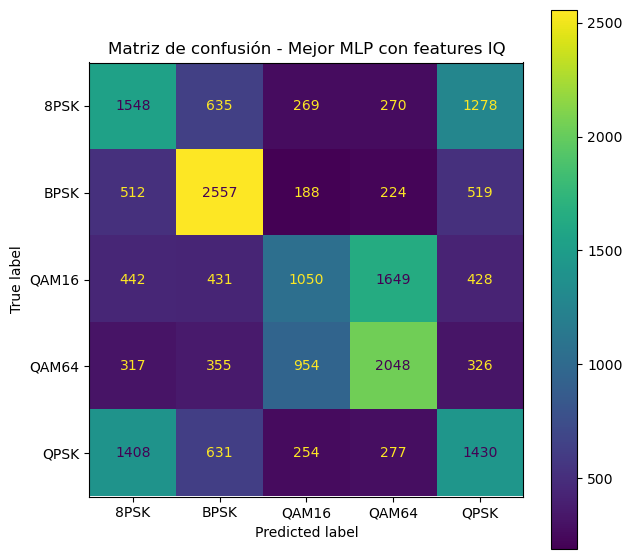

In [51]:
y_pred_best_mlp, accuracy_best_mlp = evaluar_modelo(
    best_mlp,
    X_test,
    y_test,
    "Mejor MLP con features IQ"
)

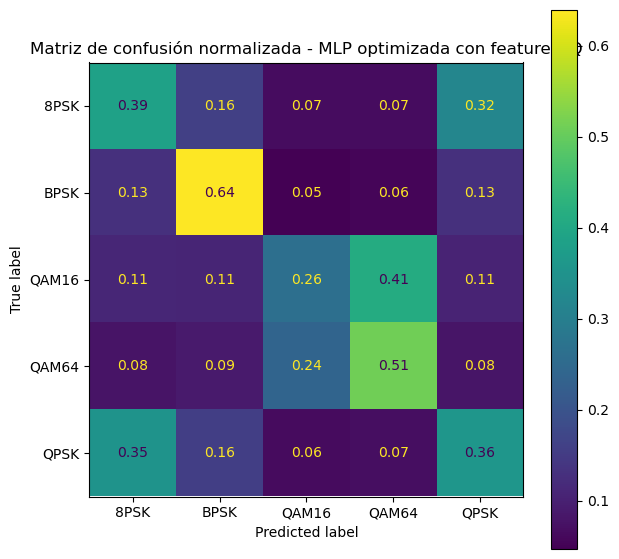

In [52]:
cm_norm = confusion_matrix(
    y_test,
    y_pred_best_mlp,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=label_encoder.classes_
)

disp.plot(ax=ax, values_format=".2f")
plt.title("Matriz de confusión normalizada - MLP optimizada con features IQ")
plt.show()

Accuracy Mejor Regresión Logística L2 con features IQ: 0.3436

              precision    recall  f1-score   support

        8PSK       0.33      0.30      0.31      4000
        BPSK       0.48      0.45      0.47      4000
       QAM16       0.29      0.28      0.28      4000
       QAM64       0.29      0.33      0.31      4000
        QPSK       0.34      0.36      0.35      4000

    accuracy                           0.34     20000
   macro avg       0.35      0.34      0.34     20000
weighted avg       0.35      0.34      0.34     20000



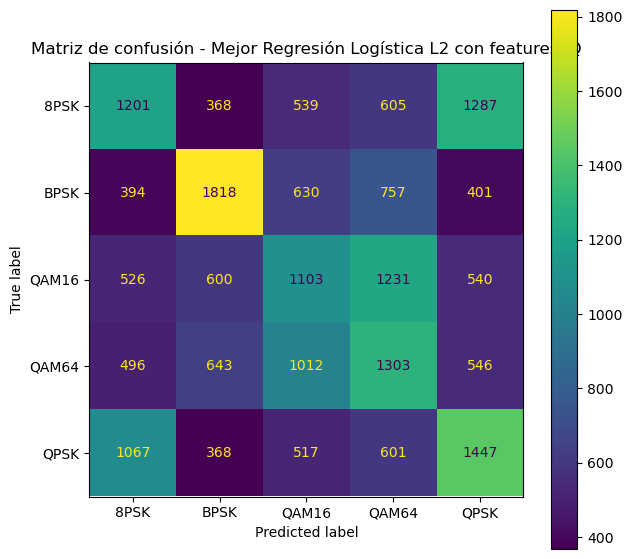

In [53]:
y_pred_best_logreg, accuracy_best_logreg = evaluar_modelo(
    best_logreg,
    X_test,
    y_test,
    "Mejor Regresión Logística L2 con features IQ"
)

In [54]:
accuracy_mlp_segura = 0.3454

resumen_modelos = pd.DataFrame({
    "Modelo": [
        "MLP con IQ crudo",
        "Regresión Logística L2 con features IQ",
        "MLP inicial con features IQ",
        "MLP optimizada con features IQ"
    ],
    "Accuracy test": [
        accuracy_mlp_segura,
        accuracy_best_logreg,
        accuracy_mlp_initial,
        accuracy_best_mlp
    ],
    "Rol en el análisis": [
        "Referencia inicial",
        "Modelo base lineal",
        "Modelo no optimizado",
        "Modelo final seleccionado"
    ]
})

resumen_modelos

,Modelo,Accuracy test,Rol en el análisis
0,MLP con IQ crudo,0.34540,Referencia inicial
1,Regresión Logística L2 con features IQ,0.34360,Modelo base lineal
2,MLP inicial con features IQ,0.43920,Modelo no optimizado
3,MLP optimizada con features IQ,0.43165,Modelo final seleccionado


## Evaluación por SNR

#### Evaluación por nivel de SNR

Como el dataset contiene señales con diferentes niveles de SNR, se analiza el accuracy del mejor modelo MLP según el nivel de ruido. Esto permite evaluar si el modelo clasifica mejor cuando la señal tiene menos ruido y si presenta dificultades cuando el SNR es bajo.

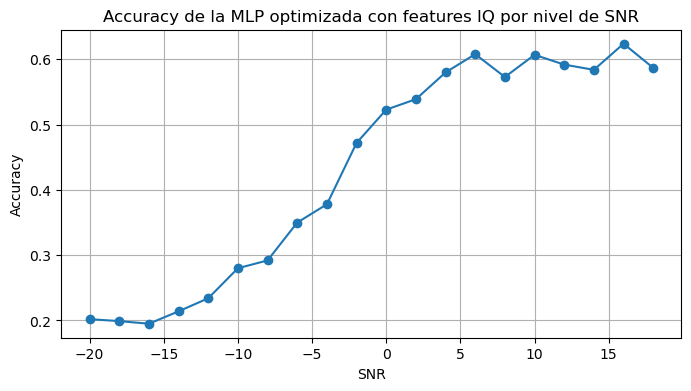

snr
-20    0.202
-18    0.199
-16    0.195
-14    0.214
-12    0.234
-10    0.280
-8     0.292
-6     0.350
-4     0.378
-2     0.472
 0     0.523
 2     0.539
 4     0.580
 6     0.608
 8     0.573
 10    0.607
 12    0.592
 14    0.584
 16    0.624
 18    0.587
Name: correct, dtype: float64

In [55]:
df_eval_snr = pd.DataFrame({
    "y_true": label_encoder.inverse_transform(y_test),
    "y_pred": label_encoder.inverse_transform(y_pred_best_mlp),
    "snr": snr_test
})

df_eval_snr["correct"] = df_eval_snr["y_true"] == df_eval_snr["y_pred"]

accuracy_by_snr = df_eval_snr.groupby("snr")["correct"].mean()

plt.figure(figsize=(8, 4))
plt.plot(accuracy_by_snr.index, accuracy_by_snr.values, marker="o")
plt.title("Accuracy de la MLP optimizada con features IQ por nivel de SNR")
plt.xlabel("SNR")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

accuracy_by_snr

La evaluación por SNR muestra que el desempeño del modelo depende fuertemente del nivel de ruido. En valores bajos de SNR, el accuracy se mantiene cercano al azar debido a la alta interferencia sobre la señal. A medida que el SNR aumenta, la señal se vuelve más clara y el modelo mejora su capacidad de clasificación. Esto confirma que el ruido es un factor crítico en la clasificación automática de modulaciones digitales.

## Comparación estadística entre dos técnicas ML

#### Comparación estadística entre MLP y Regresión Logística L2

Se realiza una comparación estadística entre los dos modelos optimizados: MLP y Regresión Logística L2. Para ello se utiliza repeated k-fold cross-validation, obteniendo múltiples valores de accuracy para cada modelo.

Posteriormente, se aplica la prueba de Wilcoxon para evaluar si existe una diferencia estadísticamente significativa entre los desempeños de ambos modelos.

La hipótesis nula establece que no existe diferencia significativa entre los modelos. Si el valor p es menor que 0.05, se rechaza la hipótesis nula y se concluye que existe evidencia estadística de diferencia entre ambos clasificadores.

In [56]:
from sklearn.model_selection import cross_val_score
from scipy.stats import wilcoxon

COMPARE_SIZE = 40000

stratify_compare_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_train, snr_train)
])

X_compare, _, y_compare, _, snr_compare, _ = train_test_split(
    X_train,
    y_train,
    snr_train,
    train_size=COMPARE_SIZE,
    random_state=42,
    stratify=stratify_compare_key
)

cv_compare = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)

stratify_compare_cv_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_compare, snr_compare)
])

cv_splits_compare = list(cv_compare.split(X_compare, stratify_compare_cv_key))

mlp_scores = cross_val_score(
    best_mlp,
    X_compare,
    y_compare,
    cv=cv_splits_compare,
    scoring="accuracy",
    n_jobs=-1
)

logreg_scores = cross_val_score(
    best_logreg,
    X_compare,
    y_compare,
    cv=cv_splits_compare,
    scoring="accuracy",
    n_jobs=-1
)

print("Scores MLP:", mlp_scores)
print("Scores Regresión Logística L2:", logreg_scores)

print("Media MLP:", np.mean(mlp_scores))
print("Desviación estándar MLP:", np.std(mlp_scores))

print("Media Regresión Logística L2:", np.mean(logreg_scores))
print("Desviación estándar Regresión Logística L2:", np.std(logreg_scores))

stat, p_value = wilcoxon(mlp_scores, logreg_scores)

print("Estadístico Wilcoxon:", stat)
print("p-value:", p_value)

Scores MLP: [0.404125 0.41225  0.41125  0.395625 0.412125 0.39775  0.410125 0.4045
 0.394625 0.397625]
Scores Regresión Logística L2: [0.3455   0.349625 0.333    0.341625 0.345125 0.34225  0.34675  0.34325
 0.340875 0.35375 ]
Media MLP: 0.404
Desviación estándar MLP: 0.006798207484329973
Media Regresión Logística L2: 0.344175
Desviación estándar Regresión Logística L2: 0.005267886198467085
Estadístico Wilcoxon: 0.0
p-value: 0.001953125


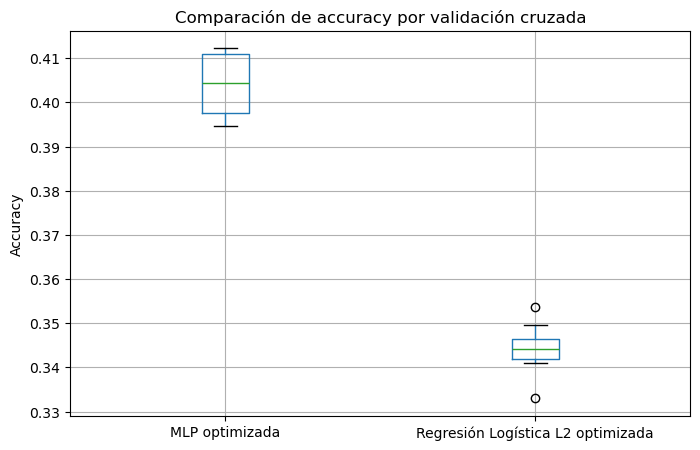

In [57]:
comparison_df = pd.DataFrame({
    "MLP optimizada": mlp_scores,
    "Regresión Logística L2 optimizada": logreg_scores
})

comparison_df.boxplot(figsize=(8, 5))
plt.title("Comparación de accuracy por validación cruzada")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

Los resultados de validación cruzada muestran que la MLP optimizada obtiene una media de accuracy superior a la Regresión Logística L2. La prueba de Wilcoxon presenta un valor p menor a 0.05, por lo que se rechaza la hipótesis nula de igualdad de desempeño. Esto indica que existe una diferencia estadísticamente significativa entre ambos modelos, favoreciendo a la MLP.

Este resultado sugiere que el problema de clasificación de modulaciones digitales requiere capturar relaciones no lineales entre las características, algo que la Regresión Logística L2, al ser un modelo lineal, no logra representar con la misma capacidad.

## Curva de aprendizaje

La curva de aprendizaje muestra una diferencia entre el error de entrenamiento y el error de validación, lo que evidencia sobreajuste moderado. El modelo aprende mejor sobre los datos de entrenamiento que sobre los datos de validación. Sin embargo, el error de validación disminuye conforme aumenta el tamaño del conjunto de entrenamiento, lo que sugiere que el modelo podría beneficiarse de una mayor cantidad o diversidad de datos.

Para reducir este sobreajuste se aplicaron regularización L2 mediante `alpha`, selección de características mediante `SelectKBest` y una arquitectura MLP más controlada. Aun así, la brecha no desaparece completamente, por lo que una mejora futura sería utilizar modelos especializados para señales temporales, como CNN 1D.

In [58]:
from sklearn.model_selection import learning_curve, RepeatedStratifiedKFold

LC_SIZE = 40000

# Crear clave de estratificación combinando clase y SNR
stratify_lc_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_train, snr_train)
])

X_lc, _, y_lc, _, snr_lc, _ = train_test_split(
    X_train,
    y_train,
    snr_train,
    train_size=LC_SIZE,
    random_state=42,
    stratify=stratify_lc_key
)

print("X_lc:", X_lc.shape)
print("y_lc:", y_lc.shape)
print("snr_lc:", snr_lc.shape)

X_lc: (40000, 784)
y_lc: (40000,)
snr_lc: (40000,)


In [59]:
cv_lc = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=1,
    random_state=42
)

stratify_lc_cv_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_lc, snr_lc)
])

cv_splits_lc = list(
    cv_lc.split(X_lc, stratify_lc_cv_key)
)

print("Número de folds para learning curve:", len(cv_splits_lc))

Número de folds para learning curve: 3


In [60]:
train_sizes, train_scores, val_scores = learning_curve(
    best_mlp,
    X_lc,
    y_lc,
    cv=cv_splits_lc,
    scoring="accuracy",
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0],
    n_jobs=-1
)

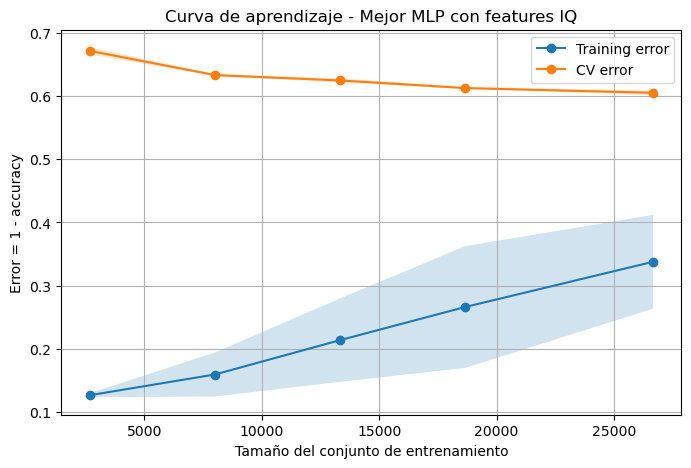

In [61]:
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

train_error = 1 - train_mean
val_error = 1 - val_mean

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_error,
    marker="o",
    label="Training error"
)

plt.plot(
    train_sizes,
    val_error,
    marker="o",
    label="CV error"
)

plt.fill_between(
    train_sizes,
    train_error - train_std,
    train_error + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_error - val_std,
    val_error + val_std,
    alpha=0.2
)

plt.title("Curva de aprendizaje - Mejor MLP con features IQ")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Error = 1 - accuracy")
plt.legend()
plt.grid(True)
plt.show()

La visualización t-SNE muestra que las clases no se separan completamente en el espacio de características seleccionado. Esto explica las confusiones observadas en la matriz de confusión, especialmente entre modulaciones con patrones cercanos como QAM16 y QAM64, o entre modulaciones de fase como 8PSK y QPSK.

Aun así, la representación con features IQ permitió mejorar el desempeño respecto al uso exclusivo de señales IQ crudas, lo que confirma que la extracción de características aportó información relevante para el modelo.

## Visualización con t-SNE

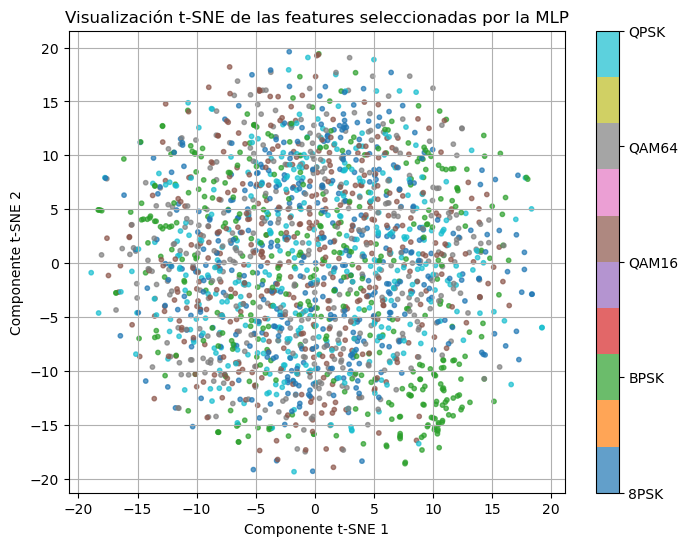

In [62]:
from sklearn.manifold import TSNE

np.random.seed(42)

sample_size = 2000

idx = np.random.choice(
    np.arange(X_test.shape[0]),
    size=sample_size,
    replace=False
)

X_sample = X_test[idx]
y_sample = y_test[idx]

# Aplicar el preprocesamiento del mejor pipeline: scaler + feature_selection
X_sample_processed = best_mlp[:-1].transform(X_sample)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample_processed)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_sample,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.title("Visualización t-SNE de las features seleccionadas por la MLP")
plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")

cbar = plt.colorbar(scatter)
cbar.set_ticks(range(len(label_encoder.classes_)))
cbar.set_ticklabels(label_encoder.classes_)

plt.grid(True)
plt.show()

Se utiliza t-SNE para proyectar el espacio de características a dos dimensiones. Cada punto representa una señal IQ y el color representa la modulación real. Esta visualización permite observar si las clases forman agrupamientos o si existe superposición entre modulaciones.

Debido al costo computacional de t-SNE, se utiliza una muestra del conjunto de prueba.

## Referencias

[1] T. J. O'Shea y N. West, “Radio Machine Learning Dataset Generation with GNU Radio,” 2016.

[2] T. J. O'Shea, J. Corgan y T. C. Clancy, “Convolutional Radio Modulation Recognition Networks,” Engineering Applications of Neural Networks, 2016.

[3] Scikit-learn Developers, “Scikit-learn: Machine Learning in Python,” documentación oficial, 2024.

[4] L. van der Maaten y G. Hinton, “Visualizing Data using t-SNE,” Journal of Machine Learning Research, vol. 9, pp. 2579–2605, 2008.

## Conclusiones

La clasificación automática de modulaciones digitales a partir de señales IQ permitió evidenciar la importancia de una adecuada representación de los datos antes del entrenamiento de los modelos. En la primera versión del experimento, basada únicamente en las señales IQ crudas aplanadas, la MLP alcanzó un accuracy de 0.3454. Posteriormente, al incorporar características derivadas de la señal, como amplitud, potencia y fase circular, el desempeño del modelo mejoró de forma considerable, alcanzando un accuracy aproximado de 0.4316 en el conjunto de prueba. Esto demuestra que el proceso de Feature Extraction aportó información relevante para diferenciar mejor los patrones de modulación.

La creación de nuevas características permitió transformar la señal IQ original en una representación más completa. Mientras que las componentes I y Q contienen la información base de la señal, las variables derivadas permiten describir mejor propiedades físicas relacionadas con la magnitud, la energía y el comportamiento angular de cada muestra. Esta mejora confirma que, en problemas de clasificación de señales, no solo importa el modelo utilizado, sino también la calidad y pertinencia de las características entregadas al algoritmo.

La MLP optimizada con features IQ superó a la Regresión Logística L2 tanto en el conjunto de prueba como en la validación cruzada. La Regresión Logística L2 alcanzó un desempeño aproximado de 0.3436, mientras que la MLP logró un resultado superior. Esta diferencia evidencia que el problema no se resuelve adecuadamente con una frontera lineal simple, sino que requiere un modelo capaz de capturar relaciones no lineales entre las características extraídas de la señal.

La comparación estadística mediante la prueba de Wilcoxon permitió reforzar esta conclusión. El valor p obtenido fue menor a 0.05, por lo que se rechaza la hipótesis nula de igualdad de desempeño entre ambos modelos. En consecuencia, se puede afirmar que la MLP optimizada presenta un rendimiento significativamente superior al de la Regresión Logística L2 bajo el esquema de validación cruzada utilizado.

El análisis por nivel de SNR mostró que el desempeño del modelo depende directamente de la calidad de la señal. En valores bajos de SNR, el accuracy disminuye debido a la presencia de mayor ruido, lo que dificulta la identificación correcta de los patrones de modulación. En cambio, en niveles medios y altos de SNR, el modelo logra mejores resultados, confirmando que la relación señal-ruido es un factor determinante en la clasificación automática de modulaciones digitales.

La matriz de confusión permitió identificar que algunas modulaciones son más difíciles de clasificar que otras. Las principales confusiones se observan entre modulaciones con características similares, como QAM16 y QAM64, o entre modulaciones de fase como 8PSK y QPSK. Esto indica que, aunque las características derivadas mejoran el desempeño general, todavía existe superposición entre clases, especialmente cuando las señales presentan ruido o patrones cercanos entre sí.

La curva de aprendizaje evidenció la presencia de sobreajuste moderado, ya que el error de entrenamiento se mantiene por debajo del error de validación. Para reducir este problema se aplicaron estrategias como regularización L2 mediante el parámetro `alpha`, selección de características con `SelectKBest`, uso de pipelines y una arquitectura MLP más controlada. Aunque estas estrategias ayudaron a mejorar la generalización, la brecha entre entrenamiento y validación no desapareció completamente.

La visualización mediante t-SNE mostró que las clases no se separan de forma totalmente clara en el espacio de características seleccionado. Este resultado es coherente con las confusiones observadas en la matriz de confusión y con el desempeño moderado del modelo. Sin embargo, la mejora obtenida frente al uso exclusivo de IQ crudo confirma que las features IQ generadas aportan información útil para el aprendizaje automático.

En conclusión, el modelo MLP optimizado con características derivadas de señales IQ fue la alternativa más adecuada dentro del alcance del proyecto. El trabajo permitió cumplir con un flujo completo de machine learning, incluyendo EDA, Feature Extraction, Feature Selection, uso de pipelines, optimización de hiperparámetros, validación cruzada repetida, comparación estadística, análisis por SNR, curva de aprendizaje y visualización t-SNE.

Como trabajo futuro, se recomienda evaluar arquitecturas especializadas para señales temporales, como CNN 1D, LSTM o modelos híbridos, ya que podrían aprovechar directamente la estructura secuencial de las componentes I/Q. Asimismo, sería conveniente explorar características en el dominio de la frecuencia, como transformada de Fourier o espectrogramas, para determinar si permiten mejorar la separación entre modulaciones con patrones similares.
